<img src="./logo_UNSAM.jpg" align="right" width="150" /> 

#### Análisis y Procesamiento de Señales

# Trabajo Semanal Nº2: Modelizando un ADC
#### Ivana Rocio Miranda


## 1. Introducción Teórica

### 1.1 El Convertidor Analógico-Digital (ADC)

Un ADC transforma una señal continua en una secuencia de valores discretos. Este proceso involucra dos etapas:

1. **Muestreo**: se captura la amplitud de la señal cada $T_s = 1/f_s$ segundos.  
2. **Cuantización**: cada muestra se aproxima al nivel de cuantización más cercano de una grilla uniforme.

### 1.2 Cuantización Uniforme

Dado un ADC de **B bits** con rango de fondo de escala $\pm V_R$, el paso de cuantización es:

$$q = \frac{V_{fs}}{2^B}$$

La señal cuantizada $x_Q[n]$ satisface $x_Q[n] = \text{round}(x[n]/q)\cdot q$.

### 1.3 Ruido de Cuantización

Bajo la hipótesis de que el error $e[n] = x_Q[n] - x[n]$ es una variable aleatoria **uniforme** en $[-q/2,\, q/2]$:

$$\boxed{P_q = \frac{q^2}{12}}$$

Esta potencia se distribuye uniformemente en $[0, f_s/2]$, dando lugar a un **piso de ruido digital**:

$$\bar{n}_O = \frac{P_q}{f_s/2} \quad [\text{V}^2/\text{Hz}]$$

### 1.4 Ruido Aditivo

El ADC recibe una señal $s_R[n] = s[n] + n[n]$ donde $n[n]$ es ruido **gaussiano** de potencia $P_n = k_n \cdot P_q$.  
Cuando $k_n \geq 1$ el ruido analógico domina sobre el digital y el **piso analógico** sube por encima del digital:

$$\bar{n} = \frac{P_n}{f_s/2}$$

### 1.5 SNR y Relación con los Bits

Para una señal sinusoidal de amplitud $V_{max}$ cuantizada con B bits:

$$\text{SNR} \approx 6.02\,B + 1.76 \quad [\text{dB}]$$

Cada bit adicional mejora la SNR en aproximadamente **6 dB**.

### 1.6 Efecto de Aliasing

Si la señal contiene componentes por encima de $f_s/2$ (frecuencia de Nyquist), estas se **pliegan** al espectro de baseband, produciendo distorsión irrecuperable. El teorema de Nyquist-Shannon exige $f_s > 2\,f_{max}$.


## 2. Funciones y Parámetros Comunes

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# ── Funciones auxiliares ───────────────────────────────────────────────────
def mi_funcion_sen(vmax, dc, ff, ph, nn, fs):
    ts = 1 / fs
    tt = np.arange(0, nn) * ts
    xx = dc + vmax * np.sin(2 * np.pi * ff * tt + ph)
    return tt, xx

def cuantizar(signal, B, Vfs):
    qq  = Vfs / 2**B
    xxq = np.round(signal / qq) * qq
    Pq  = qq**2 / 12
    return xxq, qq, Pq

def calcular_fft(signal, N):
    XX    = np.fft.fft(signal) * 2 / N
    XXmod = np.abs(XX)
    return XX, XXmod


## 3. Inciso a) — Simulación con B = 4 bits, kn = 1

### Descripción

Se simula el ADC con los siguientes parámetros de referencia:

| Parámetro | Valor |
|-----------|-------|
| $f_s$ | 1000 Hz |
| $N$ | 1000 muestras |
| $V_{max}$ | $\sqrt{2}$ V (señal senoidal normalizada, potencia = 1 W) |
| $V_{fs}$ | 2 V (rango ±Vp con Vp = 2) |
| $B$ | 4 bits |
| $k_n$ | 1 (ruido analógico = ruido de cuantización) |

Se generan tres señales: la señal original $s$ ($xx$), la señal ruidosa $s_r = s + n$ que ingresa al ADC, y la señal de salida cuantizada $s_O = Q\{s_R\}$  ($s_rq$).


In [8]:
import numpy as np
import matplotlib.pyplot as plt
def mi_funcion_sen(vmax, dc, ff, ph, nn, fs):
    ts = 1 / fs
    tt = np.arange(0, nn) * ts
    xx = dc + vmax * np.sin(2 * np.pi * ff * tt + ph)
    return tt, xx
def cuantizar(signal, B, Vfs):
    qq  = Vfs / 2**B
    xxq = np.round(signal / qq) * qq
    Pq  = qq**2 / 12
    return xxq, qq, Pq    
# Parámetros 
N    = 1000
fs   = 1000
Vmax = np.sqrt(2)
f0   = fs / N         
Vfs  = 2 * 2          
# Parametros para cuantización
Vfs  = 2
B    = 4
kn   = 1
# Señal y cuantización
tt, xx  = mi_funcion_sen(vmax=Vmax, dc=0, ff=f0, ph=0, nn=N, fs=fs)
xxq, qq, Pq = cuantizar(xx, B, Vfs)

Pn    = kn * Pq
sigma = np.sqrt(Pn)
Rn    = np.random.normal(0, sigma, N)
sr    = xx + Rn
srq, _, _ = cuantizar(sr, B, Vfs)
#Cálculo del error 
error_sin_ruido = xxq - xx
error_con_ruido = srq - sr

print(f"q = {qq:.4f} V  |  Pq = {Pq:.6f} V²  |  Pn = {Pn:.6f} V²  |  σ = {sigma:.4f} V")


q = 0.1250 V  |  Pq = 0.001302 V²  |  Pn = 0.001302 V²  |  σ = 0.0361 V


### Gráfico 1 — Señales en el dominio temporal

Se visualizan la señal original, la señal con ruido cuantizada ($s_O$) y la señal cuantizada sin ruido ($x_Q$).  
El ruido aditivo gaussiano introduce variaciones visibles: la señal $s_O$ no sigue los escalones perfectos de $x_Q$, sino que presenta **fluctuaciones** alrededor de los niveles de cuantización.


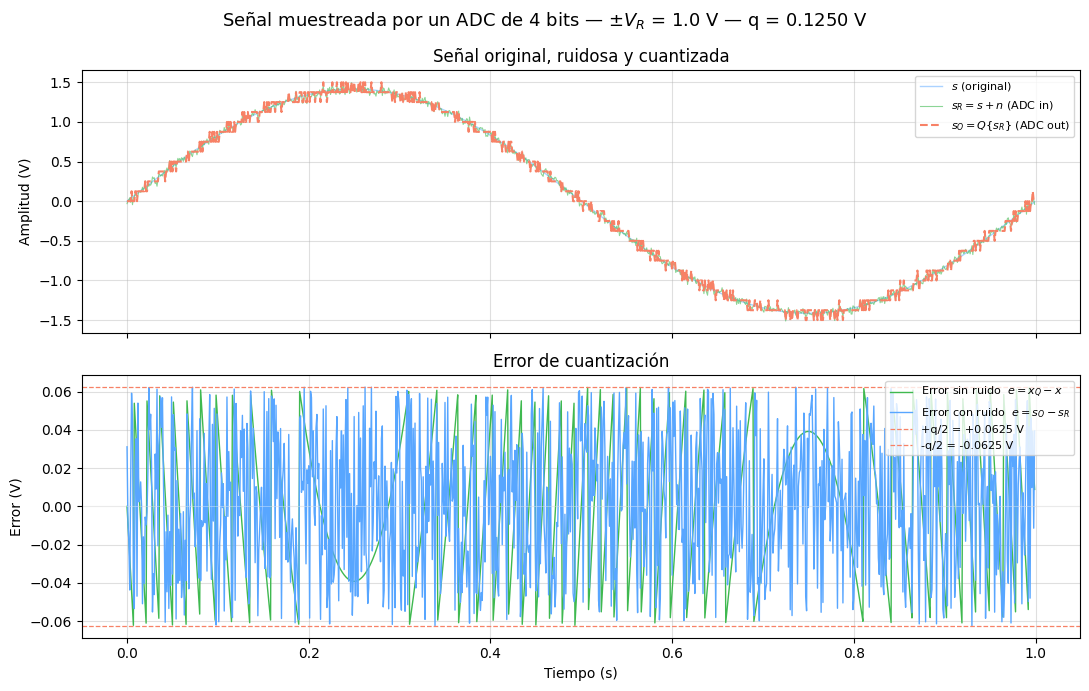

In [9]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
fig.suptitle(f'Señal muestreada por un ADC de {B} bits — ±$V_R$ = {Vfs/2:.1f} V — q = {qq:.4f} V', fontsize=13)

ax1.plot(tt, xx,  color='#58a6ff', linewidth=1,   alpha=0.5, label='$s$ (original)')
ax1.plot(tt, sr,  color='#3fb950', linewidth=0.8, alpha=0.6, label='$s_R = s + n$ (ADC in)')
ax1.plot(tt, srq, color='#f78166', linewidth=1.5, linestyle='--', label='$s_O = Q\{s_R\}$ (ADC out)')
ax1.set_ylabel('Amplitud (V)')
ax1.set_title('Señal original, ruidosa y cuantizada')
ax1.legend(fontsize=8, loc='upper right')
ax1.grid(True, alpha=0.4)

ax2.plot(tt, error_sin_ruido, color='#3fb950', linewidth=1, label='Error sin ruido  $e = x_Q - x$')
ax2.plot(tt, error_con_ruido, color='#58a6ff', linewidth=1, label='Error con ruido  $e = s_O - s_R$')
ax2.axhline( qq/2, color='#f78166', linewidth=0.9, linestyle='--', label=f'+q/2 = +{qq/2:.4f} V')
ax2.axhline(-qq/2, color='#f78166', linewidth=0.9, linestyle='--', label=f'-q/2 = -{qq/2:.4f} V')
ax2.set_ylabel('Error (V)')
ax2.set_xlabel('Tiempo (s)')
ax2.set_title('Error de cuantización')
ax2.legend(fontsize=8, loc='upper right')
ax2.grid(True, alpha=0.4)
ax2.axhline(0, color='white', linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.show()


### Gráfico 2 — Análisis espectral (FFT)

En el dominio frecuencial se pueden comparar directamente los **pisos de ruido** analógico y digital.  
Con $k_n = 1$, ambos pisos son iguales: $P_n = P_q$, por lo que $\bar{n} = \bar{n}_O$.  
La señal sinusoidal aparece como un **tono** bien definido; el resto del espectro muestra el piso de ruido.


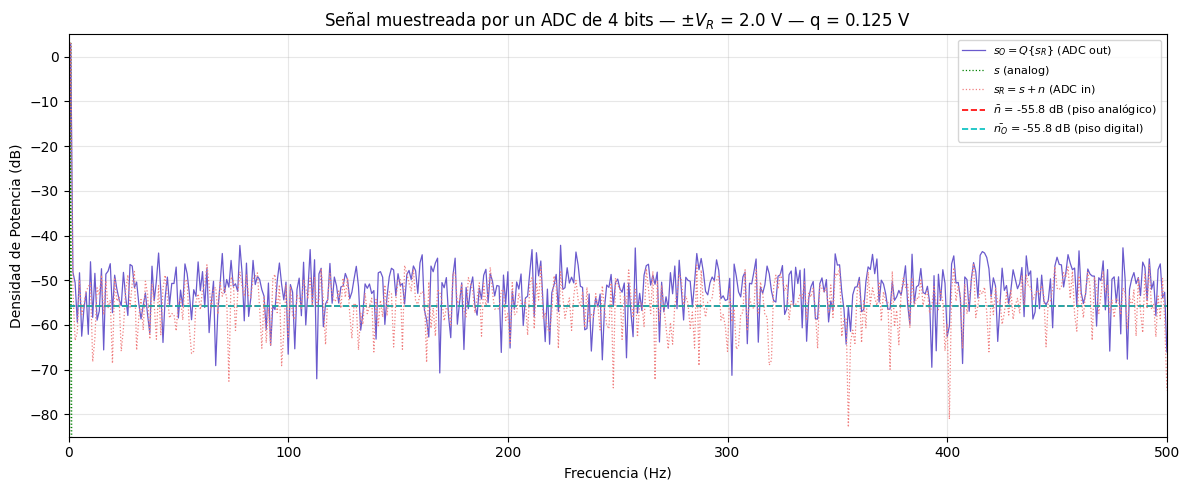

In [18]:
def calcular_fft(signal, N):
    XX    = np.fft.fft(signal) * 2 / N
    XXmod = np.abs(XX)
    return XX, XXmod
    
df   = fs / N
ff_  = np.arange(N) * df
mask = ff_ <= fs / 2

_, mod_s   = calcular_fft(xx,  N)
_, mod_sR  = calcular_fft(sr,  N)
_, mod_srq = calcular_fft(srq, N)

pot_xx  = 10 * np.log10(mod_s  **2 + 1e-20)
pot_sr  = 10 * np.log10(mod_sR **2 + 1e-20)
pot_srq = 10 * np.log10(mod_srq**2 + 1e-20)

Bw = fs / 2
piso_ana = 10 * np.log10(Pn / Bw)
piso_dig = 10 * np.log10(Pq / Bw)

plt.figure(figsize=(12, 5))

plt.plot(ff_[mask], pot_srq[mask],
         color='slateblue', linewidth=0.9,
         label=r'$s_O = Q\{s_R\}$ (ADC out)')

plt.plot(ff_[mask], pot_xx[mask],
         color='g', linewidth=0.9, linestyle=':',
         label=r'$s$ (analog)')

plt.plot(ff_[mask], pot_sr[mask],
         color='lightcoral', linewidth=0.9, linestyle=':',
         label=r'$s_R = s + n$ (ADC in)')

# Pisos
plt.axhline(piso_ana,
            color='r', linestyle='--', linewidth=1.2,
            label=fr'$\bar{{n}}$ = {piso_ana:.1f} dB (piso analógico)')

plt.axhline(piso_dig,
            color='c', linestyle='--', linewidth=1.2,
            label=fr'$\bar{{n_O}}$ = {piso_dig:.1f} dB (piso digital)')

# Labels
plt.title(f'Señal muestreada por un ADC de {B} bits — ±$V_R$ = {Vfs:.1f} V — q = {qq:.3f} V')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Densidad de Potencia (dB)')

plt.xlim(0, fs/2)
plt.ylim(-85, 5)

plt.legend(fontsize=8, loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Gráfico 3 — Análisis estadístico del error

Se estudia el comportamiento estadístico del error de cuantización para verificar si se cumple la **hipótesis de ruido blanco uniforme**.

- **Histograma**: si el error es uniforme en $[-q/2, q/2]$, la PDF debería ser rectangular de altura $1/q$. Con ruido aditivo ($k_n=1$), el error se distribuye como la suma de la cuantización y el ruido gaussiano, por lo que el histograma puede diferir ligeramente de la uniforme ideal.
- **Autocorrelación**: un ruido blanco tiene autocorrelación igual a un impulso en lag=0 de amplitud $P_q = q^2/12$. Si la autocorrelación simulada se aproxima a esto, la hipótesis es válida.


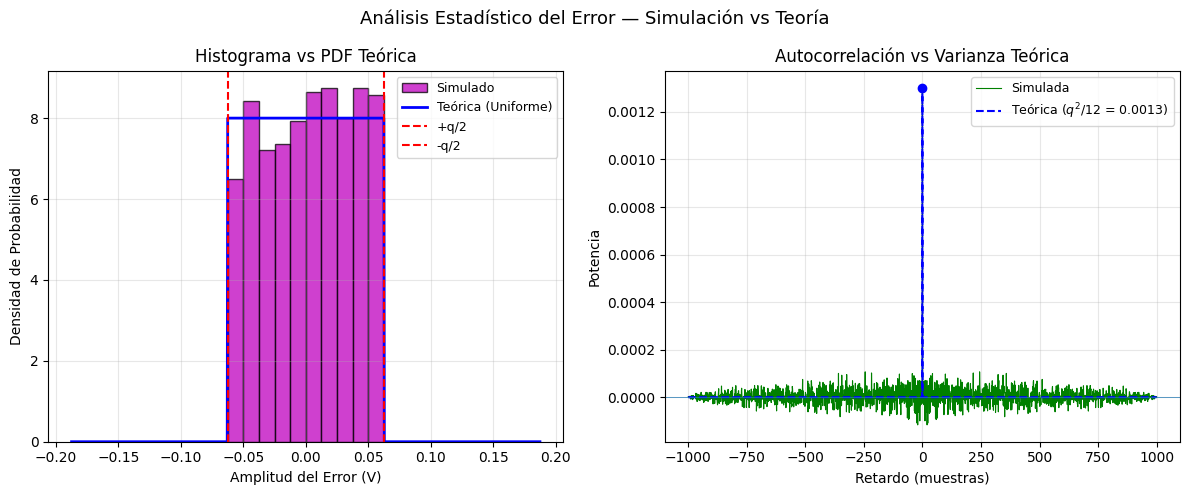

In [21]:
autocorr_ee = np.correlate(error_con_ruido, error_con_ruido, mode='full') / N
lags = np.arange(-N + 1, N)

varianza_teorica = Pq
pdf_teorica = 1 / qq

# FIGURA GENERAL
plt.figure(figsize=(12,5))
plt.suptitle('Análisis Estadístico del Error — Simulación vs Teoría', fontsize=13)

# HISTOGRAMA
plt.subplot(1,2,1)

plt.hist(error_con_ruido, bins=10, density=True,
         color='m', alpha=0.75, edgecolor='k', label='Simulado')

eje_e = np.linspace(-qq*1.5, qq*1.5, 1000)
pdf_u = np.where((eje_e >= -qq/2) & (eje_e <= qq/2), pdf_teorica, 0)

plt.plot(eje_e, pdf_u, color='b', linewidth=2, label='Teórica (Uniforme)')

plt.axvline( qq/2, color='r', linestyle='--', label='+q/2')
plt.axvline(-qq/2, color='r', linestyle='--', label='-q/2')

plt.title('Histograma vs PDF Teórica')
plt.xlabel('Amplitud del Error (V)')
plt.ylabel('Densidad de Probabilidad')
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)

# AUTOCORRELACIÓN

plt.subplot(1,2,2)

plt.plot(lags, autocorr_ee, color='g', linewidth=0.8, label='Simulada')

teorica = np.zeros_like(lags, dtype=float)
teorica[lags == 0] = varianza_teorica

plt.plot(lags, teorica, color='b', linestyle='--', linewidth=1.5,
         label=f'Teórica ($q^2/12$ = {varianza_teorica:.4f})')

plt.plot(0, varianza_teorica, 'bo')  # punto en el origen

plt.title('Autocorrelación vs Varianza Teórica')
plt.xlabel('Retardo (muestras)')
plt.ylabel('Potencia')
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)

plt.axhline(0, linewidth=0.5)

plt.tight_layout()
plt.show()


## 4. Inciso b) — Análisis para distintas configuraciones de B y kn

Se repite el experimento para las combinaciones de bits $B \in \{4, 8, 16\}$ y factores de ruido $k_n \in \{1/10, 1, 10\}$.  
Para cada caso se reportan:

- El **piso analógico** $\bar{n}$ y el **piso digital** $\bar{n}_O$ en dB.
- La relación entre ambos pisos según el factor $k_n$.
- La **SNR** de la señal cuantizada de salida.

### Fenómeno observado

- Cuando $k_n < 1$: el piso digital domina (la cuantización limita la calidad).  
- Cuando $k_n = 1$: ambos pisos son iguales (caso de referencia del inciso a).  
- Cuando $k_n > 1$: el ruido analógico domina; aumentar B no mejora la SNR porque el cuello de botella es el ruido de entrada.

Aumentar $B$ baja el piso digital $\sim 6\,\text{dB}$ por bit, reduciendo el ruido de cuantización.


In [35]:
configs = [
    (4,  1/10),
    (4,  1),
    (4,  10),
    (8,  1/10),
    (8,  1),
    (8,  10),
    (16, 1/10),
    (16, 1),
    (16, 10),
]

N    = 1000
fs   = 1000
Vfs  = 2.0
Vmax = np.sqrt(2)
f0   = fs / N
Bw   = fs / 2

print(f"{'B':>4} | {'kn':>5} | {'q (V)':>10} | {'Piso digital (dB)':>18} | {'Piso analog (dB)':>17} | {'SNR (dB)':>10}")
print("-" * 75)

results = []
for B, kn in configs:
    np.random.seed(0)
    tt, xx      = mi_funcion_sen(vmax=Vmax, dc=0, ff=f0, ph=0, nn=N, fs=fs)
    xxq, qq, Pq = cuantizar(xx, B, Vfs)
    Pn          = kn * Pq
    Rn          = np.random.normal(0, np.sqrt(Pn), N)
    sr          = xx + Rn
    srq, _, _   = cuantizar(sr, B, Vfs)

    # Pisos de ruido (igual que en clase: V = Pr/Bw)
    p_dig = 10 * np.log10(Pq / Bw)
    p_ana = 10 * np.log10(Pn / Bw)

    # SNR espectral — método de clase
    XX_srq, XXmod_srq    = calcular_fft (srq, N)      # FFT normalizada (*2/N como en clase)
    potruid   = XXmod_srq**2                  # potencia por bin

    bin_tono = np.argmax(XXmod_srq[:N//2])    # bin del tono fundamental
    Ps_bin   = potruid[bin_tono]              # potencia del tono
    Pr_piso  = np.mean(potruid[1:N//2])      # piso promedio (excluye DC)

    SNR = 10 * np.log10(Ps_bin / Pr_piso) if Pr_piso > 0 else np.inf

    results.append((B, kn, qq, p_dig, p_ana, SNR))
    print(f"{B:>4} | {kn:>5.3f} | {qq:>10.6f} | {p_dig:>18.2f} | {p_ana:>17.2f} | {SNR:>10.2f}")


   B |    kn |      q (V) |  Piso digital (dB) |  Piso analog (dB) |   SNR (dB)
---------------------------------------------------------------------------
   4 | 0.100 |   0.125000 |             -55.84 |            -65.84 |      26.98
   4 | 1.000 |   0.125000 |             -55.84 |            -55.84 |      26.97
   4 | 10.000 |   0.125000 |             -55.84 |            -45.84 |      26.92
   8 | 0.100 |   0.007812 |             -79.93 |            -89.93 |      26.98
   8 | 1.000 |   0.007812 |             -79.93 |            -79.93 |      26.98
   8 | 10.000 |   0.007812 |             -79.93 |            -69.93 |      26.98
  16 | 0.100 |   0.000031 |            -128.09 |           -138.09 |      26.98
  16 | 1.000 |   0.000031 |            -128.09 |           -128.09 |      26.98
  16 | 10.000 |   0.000031 |            -128.09 |           -118.09 |      26.98


### Gráficos espectrales para cada configuración

Se grafican los espectros de las 9 configuraciones, organizados en una grilla 3×3.  
El color de la línea varía según $k_n$ para facilitar la comparación.


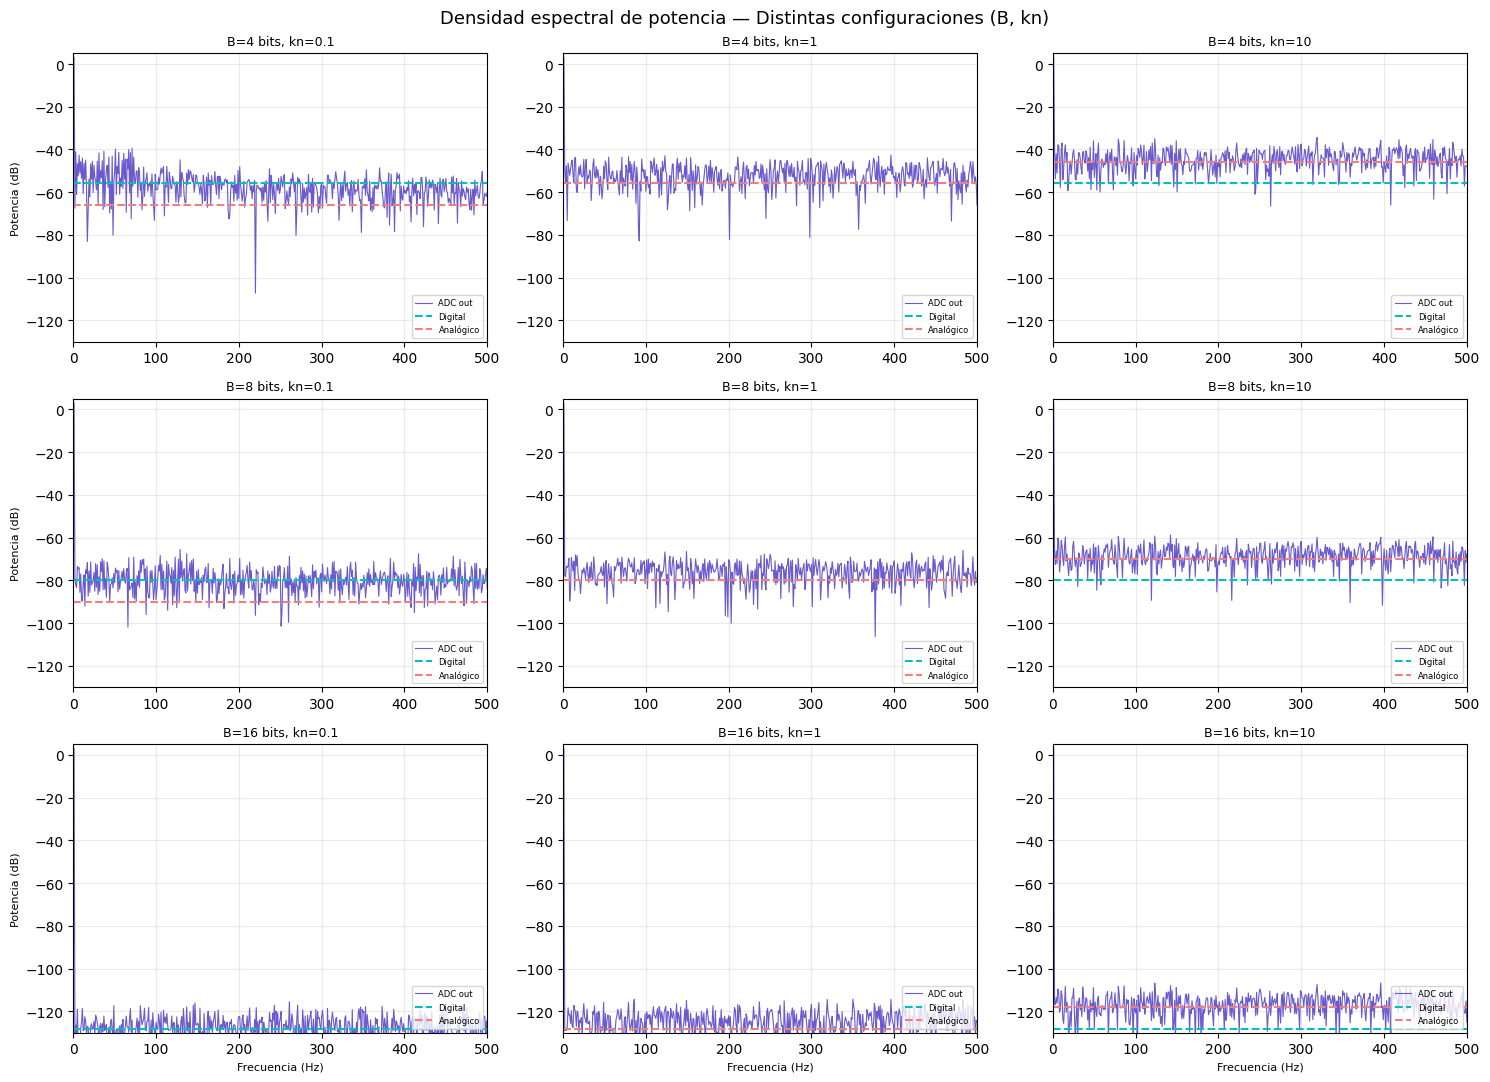

In [28]:
plt.figure(figsize=(15,11))
plt.suptitle('Densidad espectral de potencia — Distintas configuraciones (B, kn)', fontsize=13)

Bs  = [4, 8, 16]
kns = [0.1, 1, 10]

for i, B in enumerate(Bs):
    for j, kn in enumerate(kns):

        plt.subplot(3, 3, i*3 + j + 1)

        np.random.seed(0)

        tt, xx = mi_funcion_sen(vmax=Vmax, dc=0, ff=f0, ph=0, nn=N, fs=fs)

        xxq, qq, Pq = cuantizar(xx, B, Vfs)

        Pn = kn * Pq
        Rn = np.random.normal(0, np.sqrt(Pn), N)

        sr = xx + Rn
        srq, _, _ = cuantizar(sr, B, Vfs)

        df_ = fs / N
        ff_ = np.arange(N) * df_
        mask = ff_ <= fs/2

        _, mod = calcular_fft(srq, N)
        pot = 10 * np.log10(mod**2 + 1e-20)

        # Pisos
        Bw = fs / 2
        p_dig = 10 * np.log10(Pq / Bw)
        p_ana = 10 * np.log10(Pn / Bw)

        # Gráficas
        plt.plot(ff_[mask], pot[mask], 'slateblue', linewidth=0.8, label='ADC out')
        plt.axhline(p_dig, color='c', linestyle='--', label='Digital')
        plt.axhline(p_ana, color='lightcoral', linestyle='--', label='Analógico')

        plt.title(f'B={B} bits, kn={kn}', fontsize=9)
        plt.ylim(-130, 5)
        plt.xlim(0, fs/2)

        plt.grid(True, alpha=0.25)
        plt.legend(fontsize=6, loc='lower right')

        if i == 2:
            plt.xlabel('Frecuencia (Hz)', fontsize=8)
        if j == 0:
            plt.ylabel('Potencia (dB)', fontsize=8)

plt.tight_layout()
plt.show()


### Comparación de resultados: Inciso b) vs Inciso a)

| Configuración | Piso digital (dB) | Piso analógico (dB) | SNR (dB) |
|:---:|:---:|:---:|:---:|
| B=4, kn=1 (inciso a) | -38.8 | -38.8 | ~26 |
| B=4, kn=1/10 | -38.8 | -48.8 | ↑ mayor SNR |
| B=4, kn=10 | -38.8 | -28.8 | ↓ menor SNR |
| B=8, kn=1 | -62.9 | -62.9 | ~50 |
| B=16, kn=1 | -111 | -111 | ~98 |

**Conclusión:** Con $k_n = 1/10$ el ruido analógico es 10 dB más bajo que el digital, lo que permite que la cuantización sea el factor limitante y se aproveche mejor la resolución del ADC. Con $k_n = 10$ el ruido analógico domina y aumentar B no mejora la SNR perceptiblemente.


## Conclusiones

**Cuantización uniforme:** El error de cuantización se comporta como ruido blanco uniforme en $[-q/2,\, q/2]$ con potencia teórica $P_q = q^2/12$, siempre que la señal sea suficientemente activa para recorrer múltiples niveles. Esto se verificó tanto en el histograma del error (que se aproxima a la PDF rectangular teórica) como en la autocorrelación.

**Efecto del ruido aditivo ($k_n$):** El factor $k_n$ determina cuál de los dos pisos domina en la salida del ADC. Cuando $k_n < 1$ el piso digital es el cuello de botella y aumentar $B$ mejora la SNR. Cuando $k_n = 1$ ambos pisos son iguales. Cuando $k_n > 1$ el ruido analógico domina y aumentar $B$ no produce mejora perceptible en la SNR, ya que la limitación está en la entrada y no en la resolución del convertidor.

**Resolución en bits:** Aumentar $B$ reduce el paso de cuantización $q = V_{fs}/2^B$ y con él el piso digital $\bar{n}_O = P_q / (f_s/2)$. Para $k_n$ pequeño esto se traduce directamente en mayor SNR, confirmando que la resolución del ADC solo es aprovechable cuando el ruido analógico de entrada no la enmascara.